<a href="https://colab.research.google.com/github/natzasu13/BlanckProject/blob/master/Limpieza_de_datos_Tech_Layoffs_2020_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LIMPIEZA DE DATOS CON PYTHON Y PANDAS


---

# Maestria en Ciencia de Datos
## Retos en ciencia de datos - 20261 - B

**Integrantes Grupo 1**
1.   Natalia Zartha Suarez
2.   Harold Sanchez Cabezas

---
Dataset tomado de Kaggle: https://www.kaggle.com/datasets/ulrikeherold/tech-layoffs-2020-2024/data

# 1. El problema del negocio

En los ultimos años algunas empresas multinacionales en el area de tecnologíaa, como Amazon, empezaron a despedir masivamente a sus empleados. Esto genera incertidumbre en los trabajadores de estas areas de negocio y nos lleva a cuestionarnos cuáles son los factores principales que conllevan a realizar estos despidos.

Para esta limpieza de datos se tomó el dataset de Kaggle **Tech Layoffs 2020 - 2025** que nos proporciona información de los despidos tecnológicos realizados entre los años 2020 y actualizado hasta el año 2025. En este dataset podemos encontrar varios países a nivel global, pero la mayoria de registros en Estados Unidos.

Nuestra pregunta a resolver con el análisis exploratorio es:

**¿Cuáles son los principales factores que influyen en los despidos de empleados en una empresa tecnológica?**

#2. El set de datos

La dataset completo con la información recolectada de los despidos en areas de tecnología se encuentra en el archivo CSV (`tech_layoffs_til_2025.csv`) con 2412 filas y 18 columnas.

Cada registro contiene 17 características (las primeras 17 columnas) que describen el contexto de la empresa y la ubicación geográfica, y una columna de cierre que identifica el año del evento. Las columnas son:

1. "Nr": identificador único del registro (numérica)
2. "Company": nombre de la empresa que realizó los despidos (categórica)
3. "Location_HQ": ciudad de la sede principal de la empresa (categórica)
4. "Region": región geográfica de la sede (categórica)
5. "USState": estado de EE. UU., si aplica (categórica)
6. "Country": país de ubicación de la empresa (categórica)
7. "Continent": continente de ubicación de la empresa (categórica)
8. "Laid_Off": número de empleados despedidos (numérica)
9. "Date_layoffs": fecha del anuncio de los despidos (temporal)
10. "Percentage": porcentaje de despedidos (numérica: de 0 a 100)
11. "Company_Size_before_Layoffs": número de empleados antes del despido (numérica)
12. "Company_Size_after_layoffs": número de empleados después del despido (numérica)
13. "Industry": sector industrial de la empresa (categórica: "Retail", "Transportation", "Consumer", "Travel", etc.)
14. "Stage": etapa de financiación de la empresa (categórica: "Series C", "Seed", "Series B", "Post-IPO", "Acquired", etc.)
15. "Money_Raised_in__mil": dinero recaudado por la empresa en millones de dólares (numérica)
16. "Year": año en que se registraron los despidos (numérica)
17. "latitude": coordenada de latitud de la ubicación (numérica)
18. "longitude": coordenada de longitud de la ubicación (numérica)

#3. Una primera mirada al dataset

In [1]:
# Importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Lectura
from google.colab import drive
drive.mount('/gdrive')

ruta = "/gdrive/MyDrive/Colab Notebooks/retos_ciencias_de_datos/tech_layoffs_til_2025.csv"
data = pd.read_csv(ruta)

Mounted at /gdrive


In [3]:
print(data.shape)
data.head()

(2412, 18)


,Nr,Company,Location_HQ,Region,USState,Country,Continent,Laid_Off,Date_layoffs,Percentage,Company_Size_before_Layoffs,Company_Size_after_layoffs,Industry,Stage,Money_Raised_in__mil,Year,latitude,longitude
0,1,Tamara Mellon,Los Angeles,other,California,USA,North America,20.0,2020-03-12,40.0,50.0,30.0,Retail,Series C,90.0,2020,34.053691,-118.242766
1,2,HopSkipDrive,Los Angeles,other,California,USA,North America,8.0,2020-03-13,10.0,80.0,72.0,Transportation,Unknown,45.0,2020,34.053691,-118.242766
2,3,Panda Squad,San Francisco,San Francisco Bay Area,California,USA,North America,6.0,2020-03-13,75.0,8.0,2.0,Consumer,Seed,1.0,2020,37.779259,-122.419329
3,4,Help.com,Austin,other,Texas,USA,North America,16.0,2020-03-16,100.0,16.0,0.0,Support,Seed,6.0,2020,30.271129,-97.743700
4,5,Inspirato,Denver,other,Colorado,USA,North America,130.0,2020-03-16,22.0,591.0,461.0,Travel,Series C,79.0,2020,39.739236,-104.984862


In [4]:
# Veamos las variables categóricas y las numéricas
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2412 entries, 0 to 2411
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Nr                           2412 non-null   int64  
 1   Company                      2412 non-null   object 
 2   Location_HQ                  2412 non-null   object 
 3   Region                       2412 non-null   object 
 4   USState                      2411 non-null   object 
 5   Country                      2412 non-null   object 
 6   Continent                    2412 non-null   object 
 7   Laid_Off                     2040 non-null   float64
 8   Date_layoffs                 2412 non-null   object 
 9   Percentage                   1963 non-null   float64
 10  Company_Size_before_Layoffs  1769 non-null   float64
 11  Company_Size_after_layoffs   1857 non-null   float64
 12  Industry                     2412 non-null   object 
 13  Stage             

#4. Limpieza

Realizaremos el proceso de limpieza teniendo en cuenta las situaciones más comunes:

1. Datos faltantes en algunas celdas
2. Columnas irrelevantes (que no responden al problema que queremos resolver)
3. Registros (filas) repetidos
4. Valores extremos (*outliers*) en el caso de las variables numéricas. Se deben analizar en detalle pues no necesariamente la solución es eliminarlos
5. Errores tipográficos en el caso de las variables categóricas

Al final de este proceso de limpieza deberíamos tener un set de datos **íntegro**, listo para la fase de Análisis Exploratorio.

## 4.1 Datos faltantes

Acá comenzamos a ver que los datos no están completos, pues no todas las columnas tienen la misma cantidad de registros.

El número total de registros debería ser 2412. Sin embargo las columnas:
* "Laid_Off"
* "Percentage"
* "Company_Size_before_Layoffs"
* "Company_Size_after_layoffs"
* "Stage"
* "USState"
* "Money_Raised_in__mil"

Presentan datos faltantes, a continuación se detalla la cantidad de registros de datos faltantes por columna.

### 4.1.1. Detalle de valores faltantes por columna (total y porcentaje)

| Variable | Registros Nulos | Porcentaje (%) | Estado |
| :--- | :---: | :---: | :--- |
| **Company_Size_before_Layoffs** | 643 | 26.66% | Crítico |
| **Company_Size_after_layoffs** | 555 | 23.01% | Crítico |
| **Percentage** | 449 | 18.62% | Alto |
| **Laid_Off** | 372 | 15.42% | Alto |
| **Money_Raised_in__mil** | 364 | 15.09% | Alto |
| **Stage** | 164 | 6.80% | Moderado |
| **USState** | 1 | 0.04% | Mínimo |
| **Company** | 0 | 0.00% | Sin nulos |
| **Industry** | 0 | 0.00% | Sin nulos |
| **Country** | 0 | 0.00% | Sin nulos |
| **Continent** | 0 | 0.00% | Sin nulos |
| **Date_layoffs** | 0 | 0.00% | Sin nulos |
| **Year** | 0 | 0.00% | Sin nulos |
| **Location_HQ / Region** | 0 | 0.00% | Sin nulos |
| **latitude / longitude** | 0 | 0.00% | Sin nulos |
| **Nr** | 0 | 0.00% | Sin nulos |

Las columnas: **"Laid_Off", "Percentage", "Company_Size_before_Layoffs",  "Company_Size_after_layoffs", "Stage",  "Money_Raised_in__mil" **, presentan valores nulos, para un total de **768 filas con datos faltantes**, siendo esto un total de** 31.84% de filas afectadas** de todo el dataset. Este porcentaje es muy alto para hacer una eliminacion de estas filas, estariamos afectando el comportamiento del dataset inicial.

| Concepto | Valor |
| :--- | :---: |
| **Total de registros (filas)** | 2412 |
| **Filas con datos faltantes** | 768 |
| **Porcentaje de filas afectadas** | 31.84% |

In [5]:
# Contar valores nulos en TODAS las columnas del dataset
total_nulos = data.isnull().sum()

# Mostrar los resultados
print("Recuento de valores faltantes por columna:")
print(total_nulos)

print("\nPorcentaje de datos faltantes por columna:")
porcentaje_nulos = (data.isnull().sum() / len(data)) * 100
print(porcentaje_nulos.map("{:.2f}%".format))

# Análisis por filas
filas_con_nulos = data.isnull().any(axis=1).sum()
porcentaje_filas = (filas_con_nulos / len(data)) * 100

print(f"\nTotal de registros (filas): {len(data)}")
print(f"Filas con datos faltantes: {filas_con_nulos}")
print(f"Porcentaje de filas afectadas: {porcentaje_filas:.2f}%")

Recuento de valores faltantes por columna:
Nr                               0
Company                          0
Location_HQ                      0
Region                           0
USState                          1
Country                          0
Continent                        0
Laid_Off                       372
Date_layoffs                     0
Percentage                     449
Company_Size_before_Layoffs    643
Company_Size_after_layoffs     555
Industry                         0
Stage                          164
Money_Raised_in__mil           364
Year                             0
latitude                         0
longitude                        0
dtype: int64

Porcentaje de datos faltantes por columna:
Nr                              0.00%
Company                         0.00%
Location_HQ                     0.00%
Region                          0.00%
USState                         0.04%
Country                         0.00%
Continent                       0.00%
Laid

### 4.1.2. Borrar  datos faltantes

Para nuestro dataset `tech_layoffs_til_2025.csv` de información sobre despidos en el area de tecnología; no vamos a borrar los datos faltantes; ya que consideramos que un **porcentaje del 31.84% de datos faltantes** es muy alto y estariamos afectando el comportamientos de nuestros datos originales, ya que esto corresponderia a eliminar 768 filas. En lugar de esto, vamos a realizar una imputación de datos faltantes.

In [6]:
#data.dropna(inplace=True)
#data.info()

### 4.1.3. Imputación de datos faltantes

La imputación de datos faltantes, es el proceso por el cual los registros que tienen espacios vacios se completan mediante diferentes tecnicas, como: eliminar las filas, imputación con la media, mediana o moda,  usar los KNN vecinos más cercanos, entre otros.

Para nuestro dataset, consideramos la mejor opcion los KNN (K-Nearest Neighbors), k vecinos más cercanos es decir filas con caracteristicas similares.

Recordemos las columnas con datos faltantes o NAs
* "Laid_Off"
* "Percentage"
* "Company_Size_before_Layoffs"
* "Company_Size_after_layoffs"
* "Stage"
* "USState"
* "Money_Raised_in__mil"

In [7]:
from sklearn.impute import KNNImputer
import numpy as np

# Identificar columnas numéricas y categóricas con valores faltantes
numerical_cols_with_na = ['Laid_Off', 'Percentage', 'Company_Size_before_Layoffs', 'Company_Size_after_layoffs', 'Money_Raised_in__mil']
categorical_cols_with_na = ['Stage', 'USState']

# Imputación para columnas numéricas con KNN
k_imputer = KNNImputer(n_neighbors=5) # Usamos 5 vecinos, un valor común
data[numerical_cols_with_na] = k_imputer.fit_transform(data[numerical_cols_with_na])

# Imputación para columnas categóricas
# 'Stage': rellenar con 'unknown'
data['Stage'] = data['Stage'].fillna('unknown')

# 'USState': rellenar con la moda (el valor más frecuente)
data['USState'] = data['USState'].fillna(data['USState'].mode()[0])


print("Valores faltantes después de la imputación:")
print(data.isnull().sum())

Valores faltantes después de la imputación:
Nr                             0
Company                        0
Location_HQ                    0
Region                         0
USState                        0
Country                        0
Continent                      0
Laid_Off                       0
Date_layoffs                   0
Percentage                     0
Company_Size_before_Layoffs    0
Company_Size_after_layoffs     0
Industry                       0
Stage                          0
Money_Raised_in__mil           0
Year                           0
latitude                       0
longitude                      0
dtype: int64


##4.2 Columnas irrelevantes

Una columna irrelevante puede ser:

- **Una columna que no contiene información relevante para el problema que queremos resolver**. Por ejemplo, en nuestro caso, la columna `Nr` (número de registro) es un identificador único que nos ayuda a diferenciar las filas, pero no nos dice nada sobre los factores que influyen en los despidos.
- **Una columna categórica pero con un sólo nivel**. Por ejemplo, si en la columna `Continent` solo tuviésemos el nivel 'North America'", pero este no es nuestro caso, este dataset no existen columnas de este tipo. Todas las categorías (como `Industry`, `Country` o `Stage`) presentan múltiples valores, lo que las hace importantes para el análisis posterior.
- **Una columna numérica pero con un sólo valor**. Por ejemplo, si en la columna `Year` todos los valores fuesen iguales a '2020', o si `latitude` y `longitude` fueran siempre las mismas.", pero al igual que el anterior caso, en  nuestro dataset no existen columnas de este tipo.
- **Columnas con información redundante**. Por ejemplo, si además de la columna `Location_HQ` tuviésemos otra columna llamada `City_Headquarters` y ambas contuvieran exactamente la misma información de la ciudad de la sede principal." En nuestro dataset, se podria llegar a pensar que las columnas `latitude` y `longitude` **fueran redundantes respecto** a `Location_HQ`, ya que ambas representan la ubicación de la sede; pero si miramos al detalle nuestro dataset:
  * `Location_HQ` nos da el nombre de la ciudad de la sede (por ejemplo, 'Los Angeles').
  * `latitude` y `longitude` nos dan las coordenadas geográficas exactas (un punto específico en el mapa).

    Es decir que estas colmunas no son redudantes por que no nos proporcionan valores repetidos, hacen referencia a la ciudad pero con diferente información.

Si tenemos la duda de si alguna columna puede ser relevante o no lo mejor es dejarla (y más adelante en posteriores etapas podremos darnos cuenta de si se debe preservar o no).

En nuestro caso, tras verificar el dataset, hemos identificado que la columna `Nr`** es irrelevante** por tal motivo se procede a eliminarla.

In [8]:
print(f'Tamaño del set antes de intentar eliminar la columna Nr: {data.shape}')
# Comprobamos si la columna 'Nr' existe antes de intentar eliminarla
if 'Nr' in data.columns:
    data.drop('Nr', axis=1, inplace=True)
    print(f'Tamaño del set después de eliminar la columna Nr: {data.shape}')
else:
    print("La columna 'Nr' no se encuentra en el DataFrame. Probablemente ya fue eliminada.")
print("Columnas actuales en el DataFrame:", data.columns.tolist())

Tamaño del set antes de intentar eliminar la columna Nr: (2412, 18)
Tamaño del set después de eliminar la columna Nr: (2412, 17)
Columnas actuales en el DataFrame: ['Company', 'Location_HQ', 'Region', 'USState', 'Country', 'Continent', 'Laid_Off', 'Date_layoffs', 'Percentage', 'Company_Size_before_Layoffs', 'Company_Size_after_layoffs', 'Industry', 'Stage', 'Money_Raised_in__mil', 'Year', 'latitude', 'longitude']


Ahora debemos verificar que no haya columnas categóricas con un sólo nivel, o columnas numéricas con un sólo valor:

In [9]:
# Conteo de los niveles en las diferentes columnas categóricas
cols_cat = ['Company', 'Location_HQ', 'Region', 'USState', 'Country', 'Continent', 'Industry', 'Stage']

for col in cols_cat:
  print(f'Columna\u00a0{col}: {data[col].nunique()} subniveles')

Columna Company: 1713 subniveles
Columna Location_HQ: 243 subniveles
Columna Region: 5 subniveles
Columna USState: 76 subniveles
Columna Country: 49 subniveles
Columna Continent: 6 subniveles
Columna Industry: 118 subniveles
Columna Stage: 17 subniveles


Todas las columnas categóricas tienen más de 1 subnivel. No eliminaremos ninguna.

Verifiquemos lo que ocurre con las columnas numéricas:

In [10]:
data.describe()

,Laid_Off,Percentage,Company_Size_before_Layoffs,Company_Size_after_layoffs,Money_Raised_in__mil,Year,latitude,longitude
count,2412.000000,2412.000000,2412.000000,2412.000000,2412.000000,2412.000000,2412.000000,2412.000000
mean,370.101778,26.535789,5047.920596,4614.539896,735.354516,2022.905473,35.024630,-58.672372
std,1311.845769,25.853369,25950.446382,25834.724809,4076.758335,1.523281,16.757666,74.273277
min,1.000000,0.000000,0.000000,0.000000,0.000000,2020.000000,-41.288795,-123.262044
25%,50.000000,10.000000,240.750000,160.000000,58.600000,2022.000000,34.053691,-122.159847
50%,100.000000,18.000000,660.300000,505.500000,197.000000,2023.000000,37.779259,-79.383935
75%,260.000000,30.000000,1963.850000,1646.950000,493.050000,2024.000000,42.355433,-0.144055
max,30000.000000,100.000000,600000.000000,588000.000000,121900.000000,2025.000000,60.204767,174.777211


Todas las columnas numéricas tienen desviaciones estándar ("std") diferentes de cero, lo que indica que no tienen un único valor.

Preservaremos todas las columnas numéricas.

##4.3 Filas repetidas

In [11]:
print(f'Tamaño del set antes de eliminar las filas repetidas: {data.shape}')
data.drop_duplicates(inplace=True)
print(f'Tamaño del set después de eliminar las filas repetidas: {data.shape}')

Tamaño del set antes de eliminar las filas repetidas: (2412, 17)
Tamaño del set después de eliminar las filas repetidas: (2406, 17)


##4.4 *Outliers* en las variables numéricas

No siempre se deben eliminar los *outliers* porque dependiendo de la variable numérica analizada estos pueden contener información importante.

Creemos gráficas tipo "boxplot" de las columnas numéricas:

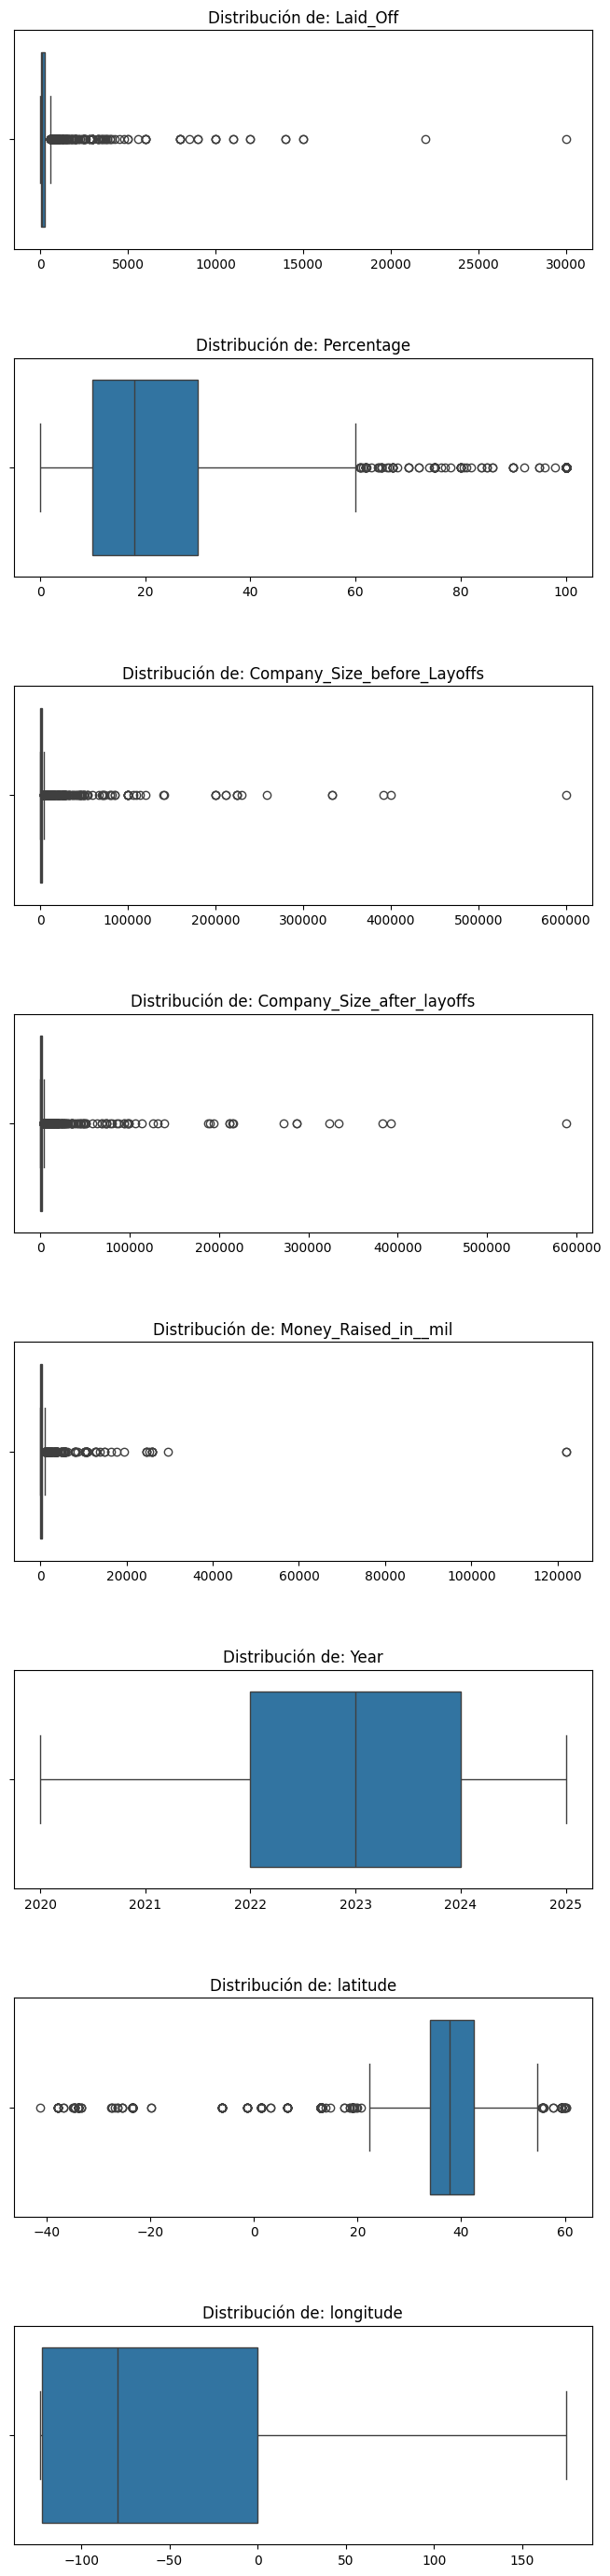

In [12]:
# Generar gráficas individuales pues las variables numéricas
# están en rangos diferentes

# Seleccionamos las variables numéricas relevantes de tu dataset
cols_num = ['Laid_Off', 'Percentage', 'Company_Size_before_Layoffs',
            'Company_Size_after_layoffs', 'Money_Raised_in__mil',
            'Year', 'latitude', 'longitude']

# Configuramos la figura, cambiamos nrows a 8 para que coincida con la lista.
fig, ax = plt.subplots(nrows=8, ncols=1, figsize=(8, 35))
fig.subplots_adjust(hspace=0.5)

# Generamos los boxplots
for i, col in enumerate(cols_num):
    sns.boxplot(x=col, data=data, ax=ax[i])
    ax[i].set_title(f'Distribución de: {col}')
    ax[i].set_xlabel('') # Limpiamos el label del eje X

plt.show()

**Observaciones:**
- "Laid_Off": hay empresas con despidos masivos que llegan hasta los 30,000 empleados.

- "Percentage": aparecen 180 casos donde echaron al 100% de la gente.

- "Money_Raised_in__mil": hay valores de plata recaudada muy altos, superando los 120,000 millones.

- "Company_Size_before_Layoffs": se ven empresas muy grandes de hasta 600,000 empleados que se salen totalmente del promedio.

In [13]:
# Eliminar filas donde los despidos superan al tamaño de la empresa
print(f'Tamaño antes de limpiar inconsistencias: {data.shape}')
data = data[data['Laid_Off'] <= data['Company_Size_before_Layoffs']]
print(f'Tamaño después de limpiar inconsistencias: {data.shape}')

Tamaño antes de limpiar inconsistencias: (2406, 17)
Tamaño después de limpiar inconsistencias: (2321, 17)


In [14]:
# Asegurarnos que el porcentaje no supere el 100%
print(f'Tamaño antes de validar porcentaje: {data.shape}')
data = data[data['Percentage'] <= 100]
print(f'Tamaño después de validar porcentaje: {data.shape}')

Tamaño antes de validar porcentaje: (2321, 17)
Tamaño después de validar porcentaje: (2321, 17)


In [15]:
# Eliminar casos donde el tamaño de la empresa sea 0 o negativo
print(f'Tamaño antes de validar tamaño de empresa: {data.shape}')
data = data[data['Company_Size_before_Layoffs'] > 0]
print(f'Tamaño después de validar tamaño de empresa: {data.shape}')

Tamaño antes de validar tamaño de empresa: (2321, 17)
Tamaño después de validar tamaño de empresa: (2321, 17)


##4.5 Errores tipográficos en variables categóricas

En una variable categórica pueden aparecer sub-niveles como "unknown" y "UNK" que para nosotros son equivalentes pero que para nuestro programa parecerían diferentes.

Se deben unificar estos sub-niveles

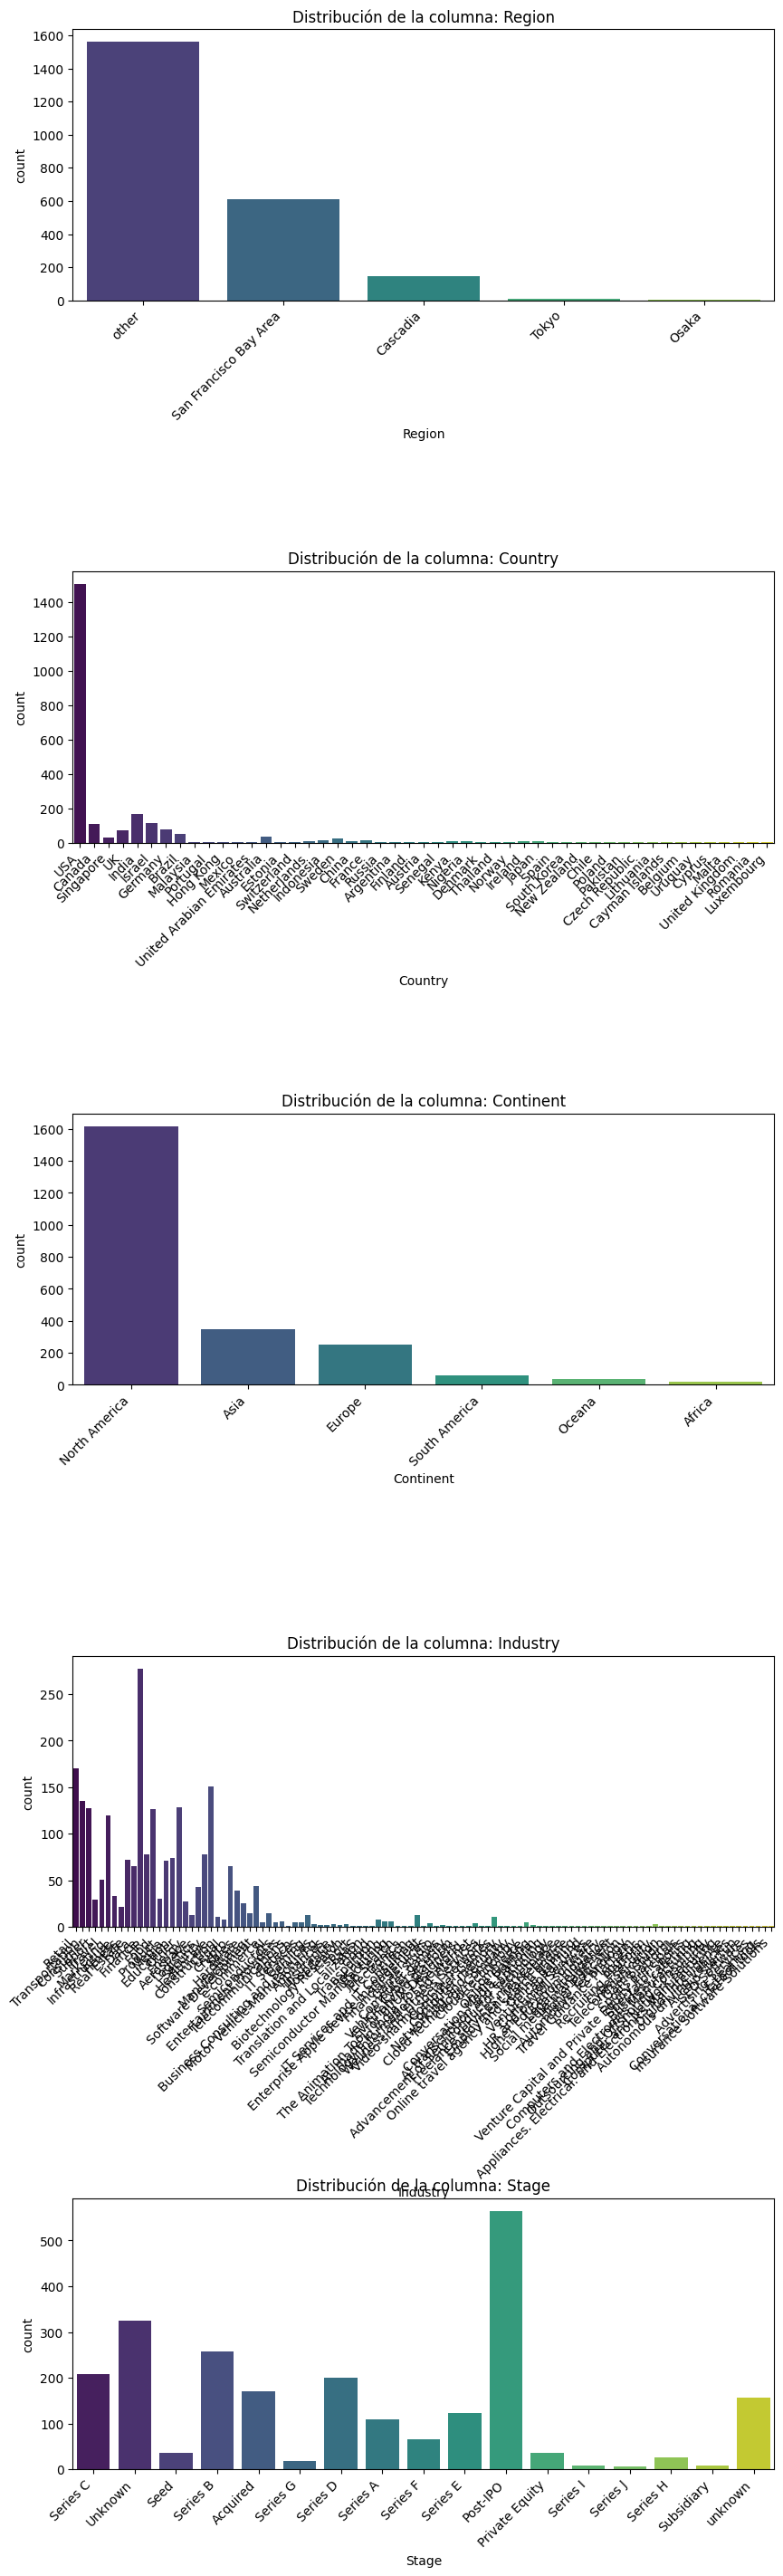

In [16]:
# Graficar los subniveles de cada variable categórica
cols_cat = ['Region', 'Country', 'Continent', 'Industry', 'Stage']

# Ajustamos nrows a 5 (por las 5 columnas)
fig, ax = plt.subplots(nrows=5, ncols=1, figsize=(10,35))
fig.subplots_adjust(hspace=1)

for i, col in enumerate(cols_cat):
  sns.countplot(x=col, data=data, ax=ax[i], palette="viridis")
  ax[i].set_title(f'Distribución de la columna: {col}')
  # Rotamos las etiquetas 45 grados para que los nombres de países e industrias no se amontonen
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=45, ha='right')

Inicialmente se observa que hay sub-niveles con el mismo nombre pero escritos en minúscula, en mayúscula o con la primera letra en mayúscula. Por ejemplo, en `Stage` tenemos 'Unknown' y 'unknown', en `Industry` encontramos 'FinTech' y 'Fintech' o 'Computer Games' y 'computer games', y en `Country` existen registros como 'UK' y 'United Kingdom' que representan el mismo país.

Unifiquemos estos sub-niveles inicialmente:

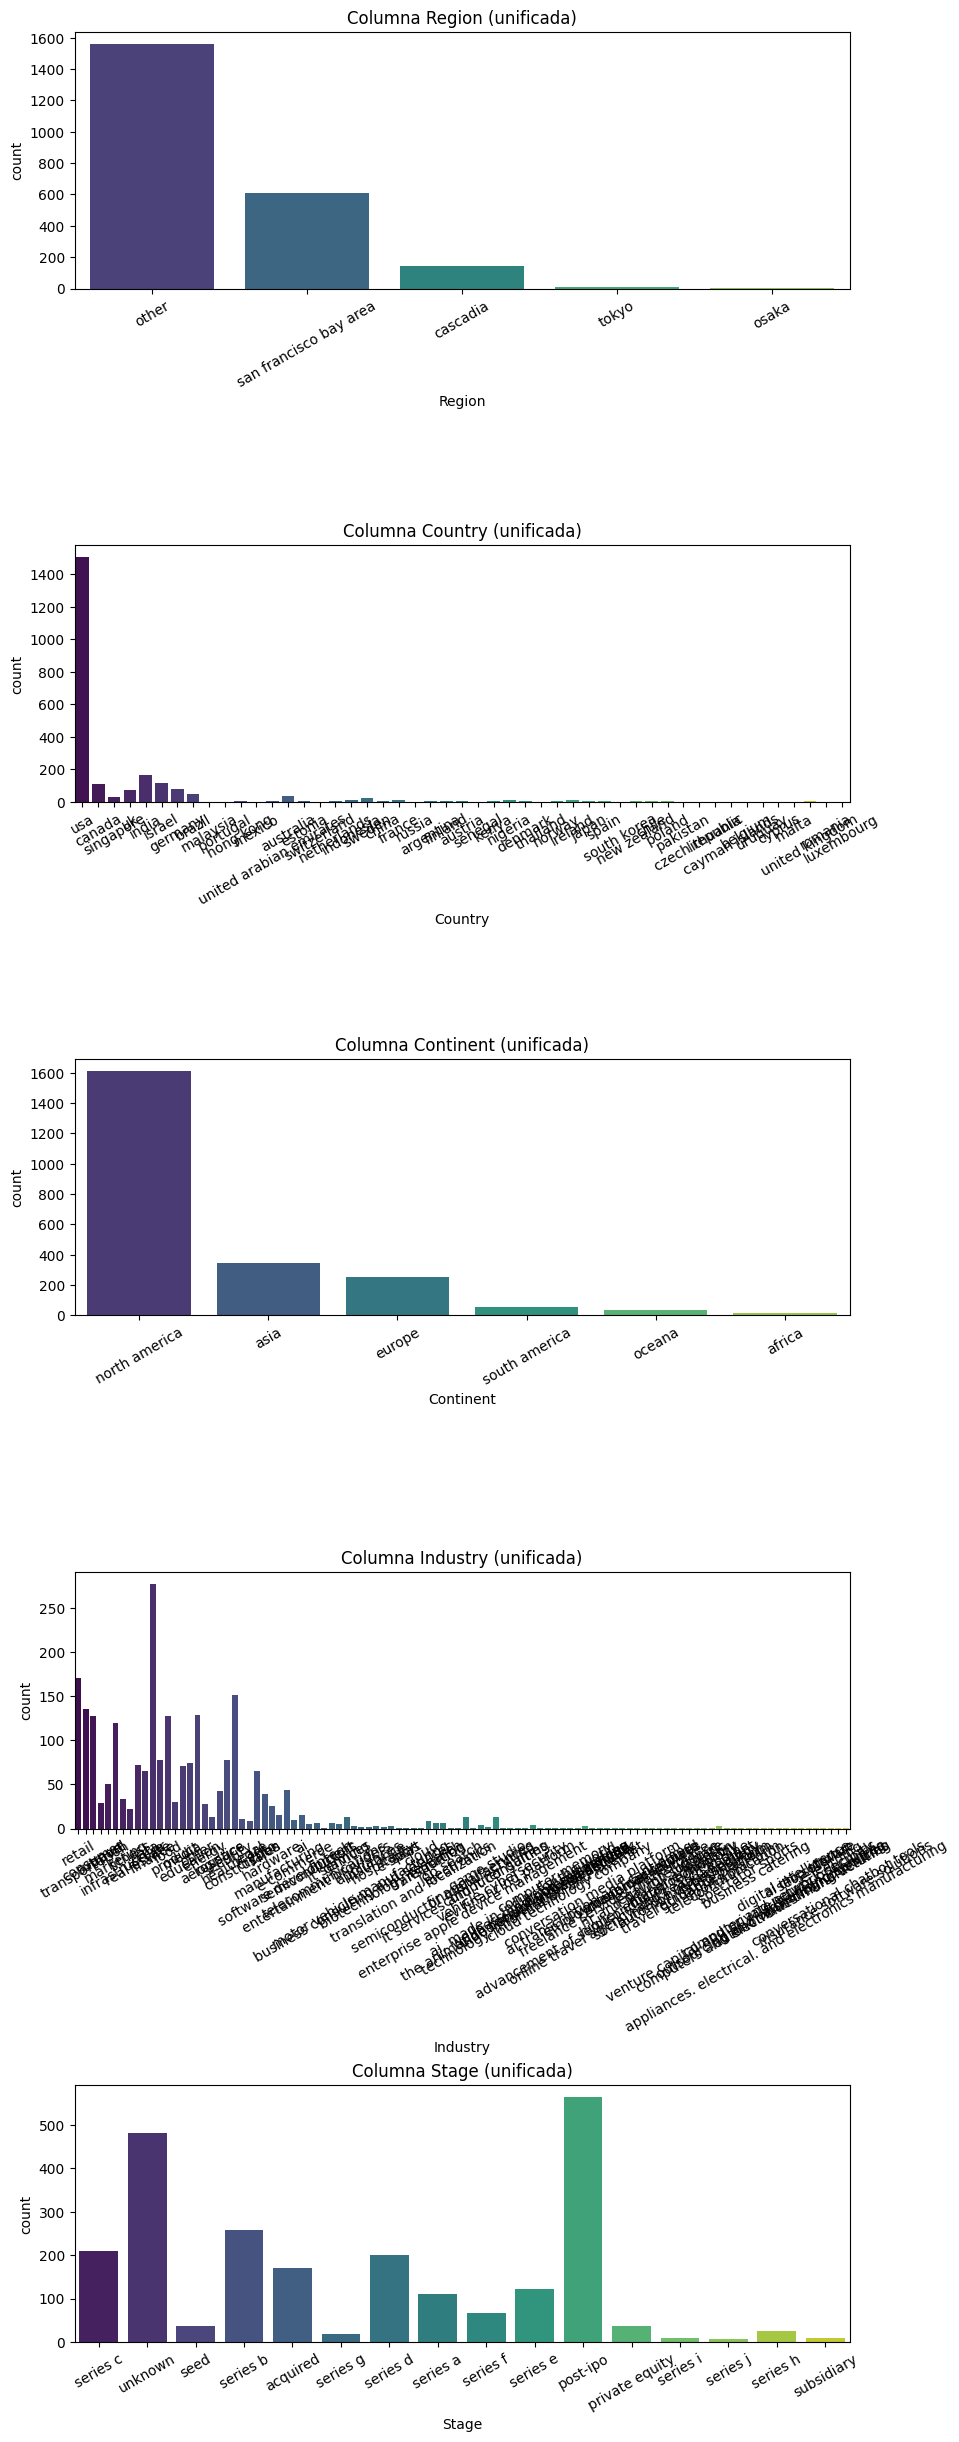

In [17]:
for column in data.columns:
    # Representar en minúsculas sólo si la columna es categórica
    if column in cols_cat:
        data[column] = data[column].str.lower()

# Y generemos las gráficas nuevamente
# Ajustamos nrows=5 porque tenemos 5 variables en cols_cat
fig, ax = plt.subplots(nrows=5, ncols=1, figsize=(10,30))
fig.subplots_adjust(hspace=1)

for i, col in enumerate(cols_cat):
  sns.countplot(x=col, data=data, ax=ax[i], palette="viridis")
  ax[i].set_title(f'Columna {col} (unificada)')
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=30)

In [18]:
# Country: unificar UK y United Kingdom, y corregir Uruquay
print(data['Country'].unique())
data['Country'] = data['Country'].replace('UK', 'United Kingdom')
data['Country'] = data['Country'].replace('Uruquay', 'Uruguay')
print(data['Country'].unique())

['usa' 'canada' 'singapore' 'uk' 'india' 'israel' 'germany' 'brazil'
 'malaysia' 'portugal' 'hong kong' 'mexico' 'united arabian emirates'
 'australia' 'estonia' 'switzerland' 'netherlands' 'indonesia' 'sweden'
 'china' 'france' 'russia' 'argentina' 'finland' 'austria' 'senegal'
 'kenya' 'nigeria' 'denmark' 'thailand' 'norway' 'ireland' 'japan' 'spain'
 'south korea' 'new zealand' 'chile' 'poland' 'pakistan' 'czech republic'
 'lithuania' 'cayman islands' 'belgium' 'uruquay' 'cyprus' 'malta'
 'united kingdom' 'romania' 'luxembourg']
['usa' 'canada' 'singapore' 'uk' 'india' 'israel' 'germany' 'brazil'
 'malaysia' 'portugal' 'hong kong' 'mexico' 'united arabian emirates'
 'australia' 'estonia' 'switzerland' 'netherlands' 'indonesia' 'sweden'
 'china' 'france' 'russia' 'argentina' 'finland' 'austria' 'senegal'
 'kenya' 'nigeria' 'denmark' 'thailand' 'norway' 'ireland' 'japan' 'spain'
 'south korea' 'new zealand' 'chile' 'poland' 'pakistan' 'czech republic'
 'lithuania' 'cayman islands' 'be

In [19]:
# Industry: unificar Logistic y Logistics, y corregir variaciones de Fintech
# Adicionalmente, corregir errores tipograficos y agrupar categorías similares

print(data['Industry'].unique())
#Agrupar las categorias similares
mapping = {
    # Hardware, Electrical y Semiconductors
    'appliances. electrical. and electronics manufacturing': 'hardware & electronics',
    'computers and electronics manufacturing': 'hardware & electronics',
    'electronics': 'hardware & electronics',
    'semiconductor manufacturing': 'semiconductors',
    'advancement of semiconductor technology': 'semiconductors',

    # Tech Genérica, IT e IA
    'technology. information and internet': 'it services',
    'it services and it consulting': 'it services',
    'information technology & services': 'it services',
    'ai. made in india. for the world.': 'ai',
    'ai chip startup': 'ai',
    'ai transcription and captioning': 'ai',
    'conversation media platform': 'ai & chatbots',
    'conversational chatbot tools': 'ai & chatbots',
    'the animation tool for ui/ux designers.': 'software development',

    # Finanzas y Seguros
    'venture capital and private equity principals': 'finance',
    'venture capital fund': 'finance',
    'financial services': 'finance',
    'insurance software solutions': 'finance',
    'insurance': 'finance',

    # Viajes y Transporte
    'travel guidance platform': 'travel',
    'online travel agency and search engine': 'travel',


    # Educación, Reclutamiento y Otros
    'higher education': 'education',
    'higher education industry': 'education',
    'educatgion': 'education',
    'recruiting platform': 'recruiting',
    'employment marketplace': 'recruiting',
    'job search': 'recruiting',
    'wellness and fitness services': 'fitness',
    'digital intelligence': 'data & analytics',
    'game studio': 'gaming',
    'online gaming': 'gaming',
    'cloud technology': 'cloud',
    'cloud technology company': 'cloud'
}

# Aplicar primero los reemplazos de texto (para corregir variaciones como plurales)
data['Industry'] = data['Industry'].str.replace('Logistic', 'Logistics', regex=False)
data['Industry'] = data['Industry'].str.replace('Logisticss', 'Logistics', regex=False)
data['Industry'] = data['Industry'].str.replace('FinTech', 'Fintech', regex=False)
data['Industry'] = data['Industry'].str.replace('telecommunication', 'telecommunications', regex=False)
data['Industry'] = data['Industry'].str.replace('telecommunicationss', 'telecommunications', regex=False)
data['Industry'] = data['Industry'].str.replace('transportion', 'transportation', regex=False)

# Aplicar el mapeo de las industrias similares
data['Industry'] = data['Industry'].replace(mapping)

['retail' 'transportation' 'consumer' 'support' 'travel' 'marketing'
 'infrastructure' 'fitness' 'real estate' 'data' 'finance' 'hr' 'food'
 'product' 'media' 'education' 'other' 'energy' 'aerospace' 'logistics'
 'security' 'healthcare' 'construction' 'legal' 'crypto' 'sales'
 'hardware' 'manufacturing' 'software development' 'e-commerce' 'ai'
 'semiconductors' 'entertainment providers' 'telecommunications' 'fintech'
 'it services' 'gaming' 'business consulting and services'
 'motor vehicle manufacturing' 'appliances' 'insurance' 'hospitality'
 'biotechnology research' 'e-sport' 'saas' 'translation and localization'
 'cloud' 'transportion' 'recruiting' 'semiconductor manufacturing'
 'job search' 'electronics' 'it services and it consulting'
 'enterprise apple device management' 'financial services' 'game studio'
 'computer games' 'vehicle cybersecurity' 'ev financing platform'
 'the animation tool for ui/ux designers.'
 'ai. made in india. for the world.'
 'technology. information and 

In [20]:
# Stage: unificar unknown y Unknown
print(data['Stage'].unique())
data.loc[data['Stage'].str.lower() == 'unknown', 'Stage'] = 'Unknown'
print(data['Stage'].unique())

['series c' 'unknown' 'seed' 'series b' 'acquired' 'series g' 'series d'
 'series a' 'series f' 'series e' 'post-ipo' 'private equity' 'series i'
 'series j' 'series h' 'subsidiary']
['series c' 'Unknown' 'seed' 'series b' 'acquired' 'series g' 'series d'
 'series a' 'series f' 'series e' 'post-ipo' 'private equity' 'series i'
 'series j' 'series h' 'subsidiary']


In [21]:
# Country: unificar USA y United States (opcional, para estandarizar)
print(data['Country'].unique())
data.loc[data['Country'] == 'USA', 'Country'] = 'United States'
print(data['Country'].unique())

['usa' 'canada' 'singapore' 'uk' 'india' 'israel' 'germany' 'brazil'
 'malaysia' 'portugal' 'hong kong' 'mexico' 'united arabian emirates'
 'australia' 'estonia' 'switzerland' 'netherlands' 'indonesia' 'sweden'
 'china' 'france' 'russia' 'argentina' 'finland' 'austria' 'senegal'
 'kenya' 'nigeria' 'denmark' 'thailand' 'norway' 'ireland' 'japan' 'spain'
 'south korea' 'new zealand' 'chile' 'poland' 'pakistan' 'czech republic'
 'lithuania' 'cayman islands' 'belgium' 'uruquay' 'cyprus' 'malta'
 'united kingdom' 'romania' 'luxembourg']
['usa' 'canada' 'singapore' 'uk' 'india' 'israel' 'germany' 'brazil'
 'malaysia' 'portugal' 'hong kong' 'mexico' 'united arabian emirates'
 'australia' 'estonia' 'switzerland' 'netherlands' 'indonesia' 'sweden'
 'china' 'france' 'russia' 'argentina' 'finland' 'austria' 'senegal'
 'kenya' 'nigeria' 'denmark' 'thailand' 'norway' 'ireland' 'japan' 'spain'
 'south korea' 'new zealand' 'chile' 'poland' 'pakistan' 'czech republic'
 'lithuania' 'cayman islands' 'be

In [22]:
data.shape

(2321, 17)

¡Y listo, ya hemos realizado la limpieza de nuestro set de datos!

Originalmente tenía 2412 registros y 18 columnas. El dataset resultante tiene 2321 filas (91 menos) y 17 columnas.

El set de datos ya está listo para el Análisis Exploratorio.

In [23]:
ruta = "/gdrive/MyDrive/Colab Notebooks/retos_ciencias_de_datos/tech_layoffs_til_2025_clean.csv"
data.to_csv(ruta, index=False)

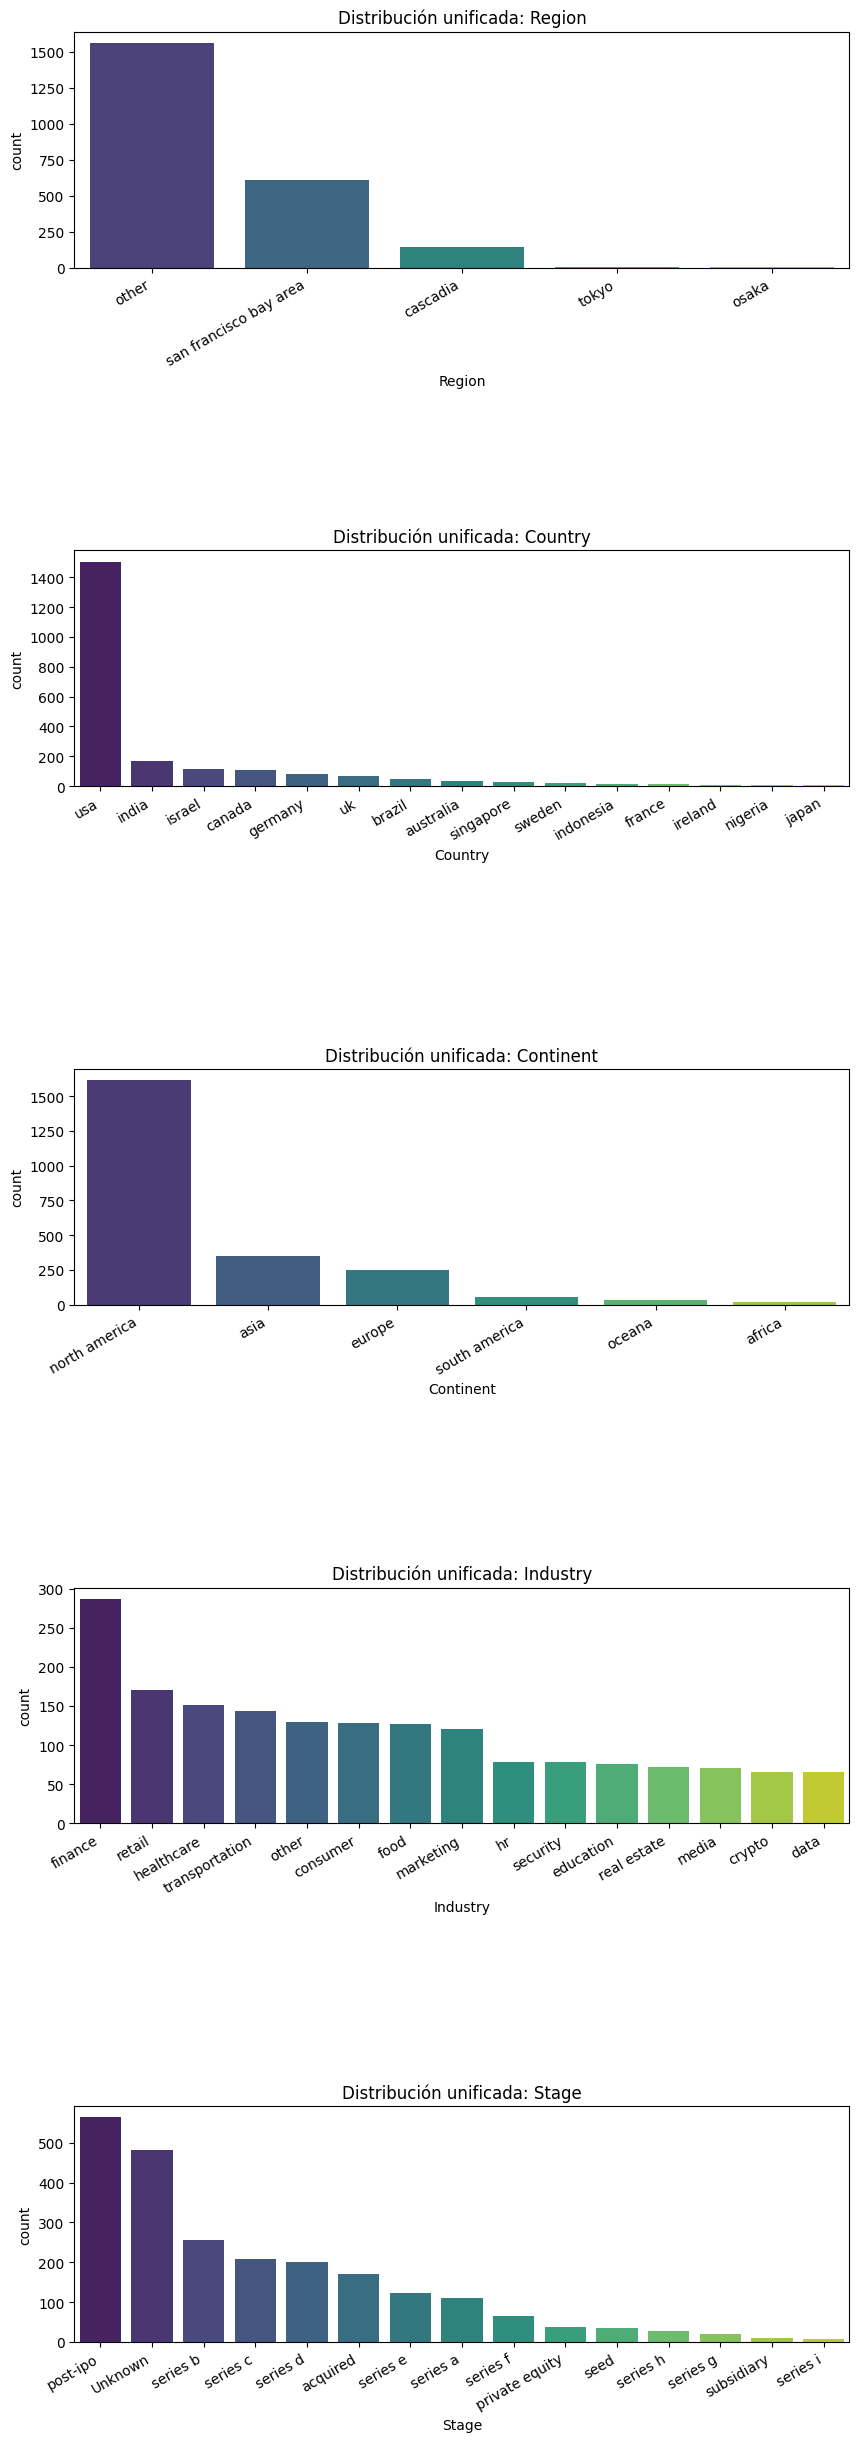

In [24]:
# Re-generamos las gráficas
# Ajustamos nrows=5 para que coincida con nuestra lista de categorías
fig, ax = plt.subplots(nrows=5, ncols=1, figsize=(10, 30))
fig.subplots_adjust(hspace=1.2)

for i, col in enumerate(cols_cat):
    # Usamos un orden basado en frecuencia para que la gráfica sea más clara (Top 15)
    sns.countplot(x=col, data=data, ax=ax[i], palette="viridis",
                  order=data[col].value_counts().iloc[:15].index)
    ax[i].set_title(f'Distribución unificada: {col}')
    ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=30, ha='right')

plt.show()

In [25]:
# Renderizar a html
!pip install nbconvert
!apt-get install texlive texlive-xetex texlive-latex-extra pandoc

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
pandoc is already the newest version (2.9.2.1-3ubuntu2).
pandoc set to manually installed.
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono
  fonts-texgyre fonts-urw-base35 libapache-pom-java libcommons-logging-java
  libcommons-parent-java libfontbox-java libgs9 libgs9-common libidn12
  libijs-0.35 libjbig2dec0 libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern poppler-data preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  teckit tex-common tex-gyre texlive-base texlive-binaries
  texlive-fonts-recommended texlive-latex-base texlive-latex-recommended
  texlive-pictures texlive-plain-generic tipa xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto f

In [26]:
import warnings
warnings.filterwarnings("ignore")

!jupyter nbconvert --to html --output "Retos_Limpieza_Tech_Layoffs_2026" "/gdrive/MyDrive/Colab Notebooks/retos_ciencias_de_datos/Limpieza-de-datos-Tech_Layoffs 2020_2025.ipynb"

[NbConvertApp] Converting notebook /gdrive/MyDrive/Colab Notebooks/retos_ciencias_de_datos/Limpieza-de-datos-Tech_Layoffs 2020_2025.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 4 image(s).
[NbConvertApp] Writing 1729081 bytes to /gdrive/MyDrive/Colab Notebooks/retos_ciencias_de_datos/Retos_Limpieza_Tech_Layoffs_2026.html
